In [46]:
import pandas as pd
import numpy as np
# from pathlib import Path

# Klasyfikacja pasażerów Titanica
Po wysłaniu raportu pozostało już tylko czekać. Dni mijały, ale w końcu telefon zadzwonił. Okazało się, że po konsultacji Twojego raportu z najbardziej doświadczonymi specjalistami w dziedzinie, zleceniodawca zdecydował się powierzyć Ci dalszą część tajemniczego zadania. Chodzi oczywiście o... **stworzenie modelu przewidującego szanse przeżycia katastrofy Titanica**.

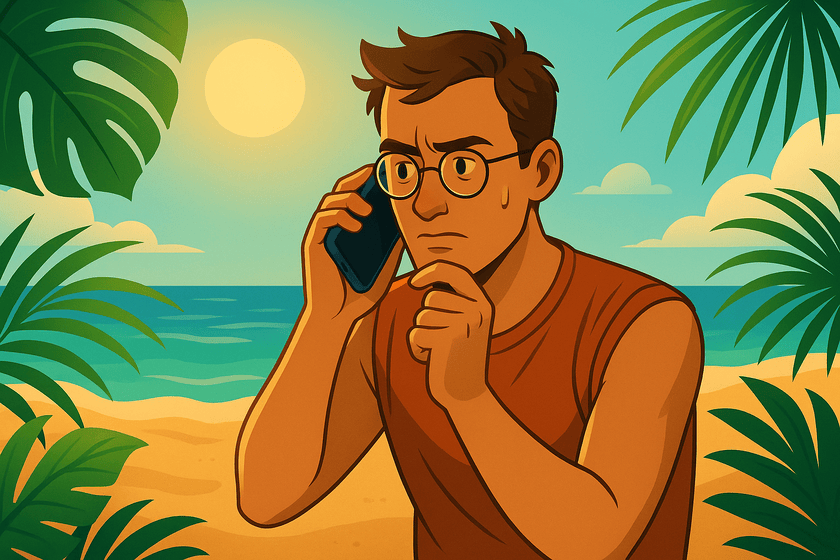

(*AI-generated image*)


#### Twoim celem będzie jest wytrenowanie modeli do klasyfikacji każdego pasażera Titanica jako ofiary (0) lub osoby, która przeżyła (1).

Poniżej znajdziesz pytania, które mogą być pomocne w zadaniu:

- Czego nauczyło Cię o badanym zbiorze danych poprzednie zadanie? Jak możesz wykorzystać wyciągnięte z niego wnioski w procesie tworzenia modelu?
- Jak przeprowadzenie standaryzacji danych może wpływać na zachowanie modelu?
- Co mój model robi i w jaki sposób?
- Jak nie przetrenować wybranego modelu?
- Jaki wynik klasyfikacji możemy uznać za *dobry*?


Wymagania:
- Wypisz obserwacje z pierwszego zadania, które pomogą Ci w tym. Co było przydatne, a co okazało się bezużyteczne?
- [Nie doprowadź](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html) do ~~przecieku statku~~ wycieku danych (np. nie ucz modelu na danych testowych). Nauczone modele odpal na danych treningowych i testowych - opisz uzyskane wyniki.
- Stwórz baseline, czyli dla porównania sprawdź jak z zadaniem radzi sobie [Dummy Classifier](https://scikit-learn.org/stable/modules/generated/sklearn.dummy.DummyClassifier.html) (jeśli Twój docelowy model radzi sobie gorzej - uciekaj)
- Przeprowadź badania na dwóch wybranych modelach uczenia maszynowego (np. spośród: drzew decyzyjnych, SVM, MLP, KNN, z gwiazdką [XGBoost](https://xgboost.readthedocs.io/en/stable))
- W badaniach użyj wybranych metryk. Wybór uzasadnij.
- Dla każdego modelu wybierz co najmniej dwa hiperparametry i przeprowadź badania zależności wyników metryk od wartości hiperparametrów. Zwizualizuj wszystko ładnie, zastanów się dlaczego tak mogło być i wyciągnij i wypisz wnioski.
- Podsumuj przeprowadzone badania, wypisz wnioski.

Niezmiennie, zadbaj o czytelność kodu i nazewnictwo zmiennych. Jeśli jakiś wycinek kodu się powtarza, to wyodrębnij go do funkcji. Postaraj się zamieszczać swoje wnioski w postaci komentarza `Markdown`.

Jeśli chcesz, możesz sprawdzić (przyjmując pewne założenia), jakie byłyby Twoje szanse na Titanicu.

Uwaga! Jeśli Titanic to dla Ciebie nic i baaaaardzo chcesz to możesz w ramach tego zadania zająć się [bardziej wymagającym](https://archive.ics.uci.edu/dataset/365/polish+companies+bankruptcy+data) zbiorem.

In [47]:
titanic_df = pd.read_csv('titanic.csv', index_col='PassengerId')

In [48]:
titanic_df['Cabin'].str[0].unique()
titanic_df.head(5)

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


Obserwacje z Zad 1:
W zbiorze wystąpowało sporo braków danych:
* Zmienna Cabin - z powodu dużych braków (ponad 77%) zastępuję ją kolumną CabinKnown
* 'Age' - uzupełnione za pomocą mediany dla każdej klasy 'Pclass' osobno
* 'Fare' - uzupołnione za pomocą mediany dla każdej klasy 'Pclass' osobno
* 'Embarked' - uzupełniam dominantą

Dodatkowe kolumny IsAlone, CabinKnown oraz CabinDeck


Jak zauważyłem w analizie z zadania 1:
* kobiety miały dużo większe szanse przeżycia niż mężczyźni,
* pasażerowie z pierwszej klasy ratowali się znacznie częściej niż ci z klas niższych. 
* młodsze osoby oraz ci, którzy mieli droższe bilety, częściej przeżywali
* osoby podróżujące samotnie miały nieco lepsze wyniki niż duże rodziny.

Następujące  kolumny okazały się raczej bezużyteczne:
* Id pasażera to tylko numer porządkowy
* pełne nazwiska czy numery biletów nie dają za dużo, bo są unikalne i nic z nich nie wynika. 
* Z kolei pełne numery kabin były często wybrakowane, więc zamiast nich lepiej było zostawić sam pokład.


Poniżej kod z dostosowaniem oraz kodowaniem danych (z listy 1):

In [49]:
# Zastąp braki w kolumnie Age medianą dla każdej z Pclass osobno
titanic_df['Age'] = titanic_df.groupby('Pclass')['Age'].transform(lambda x: x.fillna(x.median()))
print(titanic_df['Age'].isnull().sum())  # Sprawdzenie liczby braków po uzupełnieniu ok

# titanic_df['Fare'] = titanic_df.groupby('Fare')['Fare'].transform(lambda x: x.fillna(x.median()))
# titanic_df['Fare'].isnull().sum()  # Sprawdzenie liczby braków po uzupełnieniu
titanic_df['Fare'] = titanic_df.groupby('Pclass')['Fare'].transform(lambda x: x.fillna(x.median()))
print(titanic_df['Fare'].isnull().sum())  # ok

# Uzupełnij braki w kolumnie Embarked najczęściej występującą wartością
most_common_embarked = titanic_df['Embarked'].mode()[0]
titanic_df['Embarked'] = titanic_df['Embarked'].fillna(most_common_embarked)
print(titanic_df['Embarked'].isnull().sum())  # Sprawdzenie liczby braków ok


titanic_df['IsAlone'] = (titanic_df['SibSp'] + titanic_df['Parch'] > 0).astype(int)
titanic_df['CabinKnown'] = (~titanic_df['Cabin'].isnull()).astype(int)
titanic_df['CabinDeck'] = titanic_df['Cabin'].fillna('U').astype(str).str[0]


titanic_df = titanic_df.drop(columns=["Name", "Cabin", "Ticket", "SibSp", "Parch"])
print(titanic_df.columns)
titanic_df.head(50)



0
0
0
Index(['Survived', 'Pclass', 'Sex', 'Age', 'Fare', 'Embarked', 'IsAlone',
       'CabinKnown', 'CabinDeck'],
      dtype='object')


,Survived,Pclass,Sex,Age,Fare,Embarked,IsAlone,CabinKnown,CabinDeck
PassengerId,,,,,,,,,
1,0,3,male,22.0,7.2500,S,1,0,U
2,1,1,female,38.0,71.2833,C,1,1,C
3,1,3,female,26.0,7.9250,S,0,0,U
4,1,1,female,35.0,53.1000,S,1,1,C
5,0,3,male,35.0,8.0500,S,0,0,U
6,0,3,male,24.0,8.4583,Q,0,0,U
7,0,1,male,54.0,51.8625,S,0,1,E
8,0,3,male,2.0,21.0750,S,1,0,U
9,1,3,female,27.0,8.0500,S,1,0,U


In [50]:
sex_mapping = {
    'male': 0,
    'female': 1
}

titanic_df['Sex'] = titanic_df['Sex'].map(sex_mapping)



titanic_df= pd.get_dummies(data=titanic_df, prefix='CabinDeck', columns=['CabinDeck'], dtype=np.int32) # pass in dataframe and columns to one-hot code
titanic_df = pd.get_dummies(data=titanic_df, prefix='Embarked', columns=['Embarked'], dtype=np.int32)
titanic_df.head(n=1)

print(titanic_df.head)
titanic_df.info()




<bound method NDFrame.head of              Survived  Pclass  Sex   Age     Fare  IsAlone  CabinKnown  \
PassengerId                                                              
1                   0       3    0  22.0   7.2500        1           0   
2                   1       1    1  38.0  71.2833        1           1   
3                   1       3    1  26.0   7.9250        0           0   
4                   1       1    1  35.0  53.1000        1           1   
5                   0       3    0  35.0   8.0500        0           0   
...               ...     ...  ...   ...      ...      ...         ...   
887                 0       2    0  27.0  13.0000        0           0   
888                 1       1    1  19.0  30.0000        0           1   
889                 0       3    1  24.0  23.4500        1           0   
890                 1       1    0  26.0  30.0000        0           1   
891                 0       3    0  32.0   7.7500        0           0   

       

Podział danych na zbiory

In [51]:
from sklearn.model_selection import train_test_split

y = titanic_df["Survived"].astype(int).values
X = titanic_df.drop(columns=["Survived"]).copy()

# Podział train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print("Kształt X_train:", X_train.shape)
print("Kształt X_test :", X_test.shape)

Kształt X_train: (712, 18)
Kształt X_test : (179, 18)


Baseline oraz DummyClassifier

In [52]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, classification_report, f1_score
dummy = DummyClassifier(strategy="uniform")
dummy.fit(X_train, y_train)
y_pred_dummy = dummy.predict(X_test)

print("Dummy Accuracy:", accuracy_score(y_test, y_pred_dummy))
print("Classification Report:")
print(classification_report(y_test, y_pred_dummy))

Dummy Accuracy: 0.49162011173184356
Classification Report:
              precision    recall  f1-score   support

           0       0.60      0.51      0.55       110
           1       0.37      0.46      0.41        69

    accuracy                           0.49       179
   macro avg       0.49      0.49      0.48       179
weighted avg       0.51      0.49      0.50       179



Drzewo Decyzyjne

In [53]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, precision_recall_fscore_support, classification_report
from sklearn.dummy import DummyClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree
from sklearn.neighbors import KNeighborsClassifier
from sklearn.cluster import KMeans
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.metrics import accuracy_score, precision_score, recall_score

Predykcja danych testowych

In [54]:

model = DecisionTreeClassifier(max_depth=3)
drzewko = model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.77      0.92      0.83       110
           1       0.81      0.55      0.66        69

    accuracy                           0.78       179
   macro avg       0.79      0.73      0.74       179
weighted avg       0.78      0.78      0.77       179



Predykcja danych treningowych

In [55]:
y_pred_train = model.predict(X_train)
print(classification_report(y_train, y_pred_train))

              precision    recall  f1-score   support

           0       0.81      0.95      0.87       439
           1       0.89      0.64      0.74       273

    accuracy                           0.83       712
   macro avg       0.85      0.80      0.81       712
weighted avg       0.84      0.83      0.82       712



Dla danych testowych otrzymaliśmy nieco mniejszą precyzję niż dla treningowych, co może wskazywać na nieznaczne przeuczenie modelu.

KNN

In [56]:
#metryka manhattan, bo mamy kilka cech kategorycznych
model = KNeighborsClassifier(n_neighbors=25, metric='manhattan')
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.71      0.85      0.77       110
           1       0.65      0.45      0.53        69

    accuracy                           0.69       179
   macro avg       0.68      0.65      0.65       179
weighted avg       0.69      0.69      0.68       179



In [57]:
y_pred_train = model.predict(X_train)
print(classification_report(y_train, y_pred_train))

              precision    recall  f1-score   support

           0       0.74      0.88      0.81       439
           1       0.73      0.50      0.59       273

    accuracy                           0.74       712
   macro avg       0.73      0.69      0.70       712
weighted avg       0.74      0.74      0.72       712



Dla danych testowych otrzymaliśmy nieco mniejszą dokładność niż dla treningowych, co może wskazywać na lekkie przeuczenie modelu.
Poza tym widzimy, że model dobrze radzi sobie z klasyfikacją obu klas, choć precyzja dla klasy 1 (przeżyli) jest nieco niższa niż dla klasy 0 (nie przeżyli).

Ponadto widzimy, że model drzew decyzyjnych radzi sobie lepiej niż KNN, co może wynikać z charakterystyki danych i ich rozkładu.
Oba badane modele radzą sobie znacznie lepiej niż model bazowy (DummyClassifier).


Hiperparametry Drzewo Decyzyjne: badamy wybór głębokości drzewa (max_depth) oraz criterion (metody podziału).

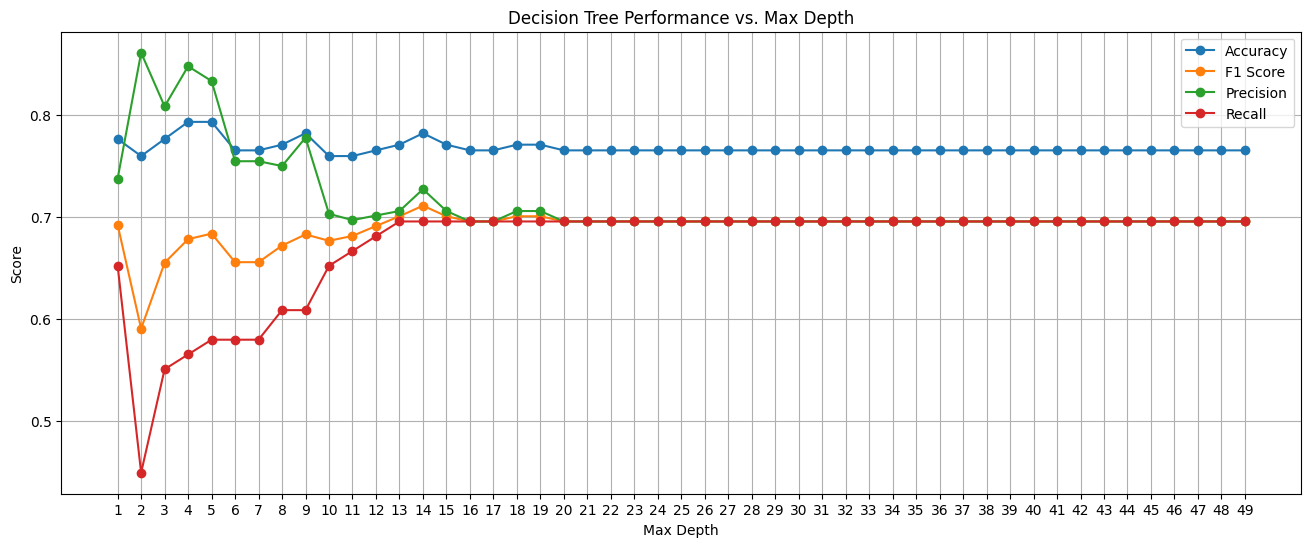

In [60]:
max_depths = range(1, 50)
tree_accuracy = []
tree_f1 = []
tree_precision = []
tree_recall = []


# Dla drzewka
for depth in max_depths:
    tree = DecisionTreeClassifier(random_state=42, max_depth=depth, criterion='gini')
    tree.fit(X_train, y_train)
    y_pred_tree = tree.predict(X_test)
    tree_accuracy.append(accuracy_score(y_test, y_pred_tree))
    tree_f1.append(f1_score(y_test, y_pred_tree))
    precision, recall, _, _ = precision_recall_fscore_support(y_test, y_pred_tree, average='binary')
    tree_precision.append(precision)    
    tree_recall.append(recall)

plt.figure(figsize=(16, 6))
plt.plot(max_depths, tree_accuracy, marker='o', label='Accuracy')
plt.plot(max_depths, tree_f1, marker='o', label='F1 Score')
plt.plot(max_depths, tree_precision, marker='o', label='Precision')
plt.plot(max_depths, tree_recall, marker='o', label='Recall')
plt.title('Decision Tree Performance vs. Max Depth')
plt.xlabel('Max Depth')
plt.ylabel('Score')
plt.xticks(max_depths)
plt.legend()
plt.grid(True)
plt.show()

Dla małych głbokości drzewa decyzyjnego obserwujemy dużą zmienność dokłądności.
Najbardziej precyzyjne odpowiedzi model udzielił dla drzew o głębokościach 4 oraz 5.
Dla coraz większych głębokości dokładność klasyfikacji maleje, a następnie od glębokości 14
stabilizuje się i już praktycznie nie zmienia.

In [61]:
criteria = ['gini', 'entropy']
accuracies = []
precisions = []
recalls = []
f1_res = []

for c in criteria:
  model = DecisionTreeClassifier(criterion = c, random_state = 21)
  model.fit(X_train, y_train)
  y_pred = model.predict(X_test)
  accuracies.append(accuracy_score(y_test, y_pred))
  precisions.append(precision_score(y_test, y_pred, average='macro'))
  recalls.append(recall_score(y_test, y_pred, average='macro'))
  f1_res.append(f1_score(y_test, y_pred, average='macro'))

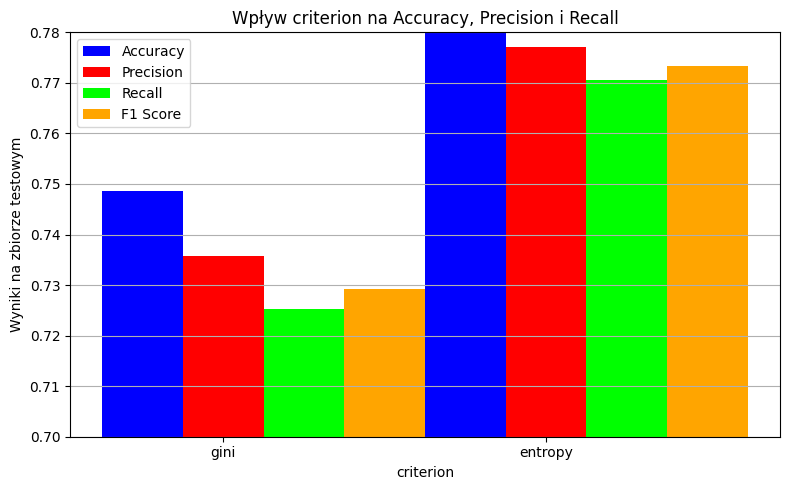

In [62]:
x = np.arange(len(criteria))
width = 0.25

plt.figure(figsize=(8, 5))
plt.bar(x - width, accuracies, width, label='Accuracy', color='blue')
plt.bar(x, precisions, width, label='Precision', color='red')
plt.bar(x + width, recalls, width, label='Recall', color='lime')
plt.bar(x + 2*width, f1_res, width, label='F1 Score', color='orange')

plt.title('Wpływ criterion na Accuracy, Precision i Recall')
plt.xlabel('criterion')
plt.ylabel('Wyniki na zbiorze testowym')
plt.xticks(x, criteria)
plt.ylim(0.7, 0.78)
plt.grid(axis='y')
plt.legend()
plt.tight_layout()
plt.show()

Dla kryterium entropy mamy znacznie lepsze wartości wszystkich wskaźników klasyfikacji.

Dla KNN zbadamy wpływ liczby sąsiadów oraz wybór metryk na dokładność klasyfikacji.

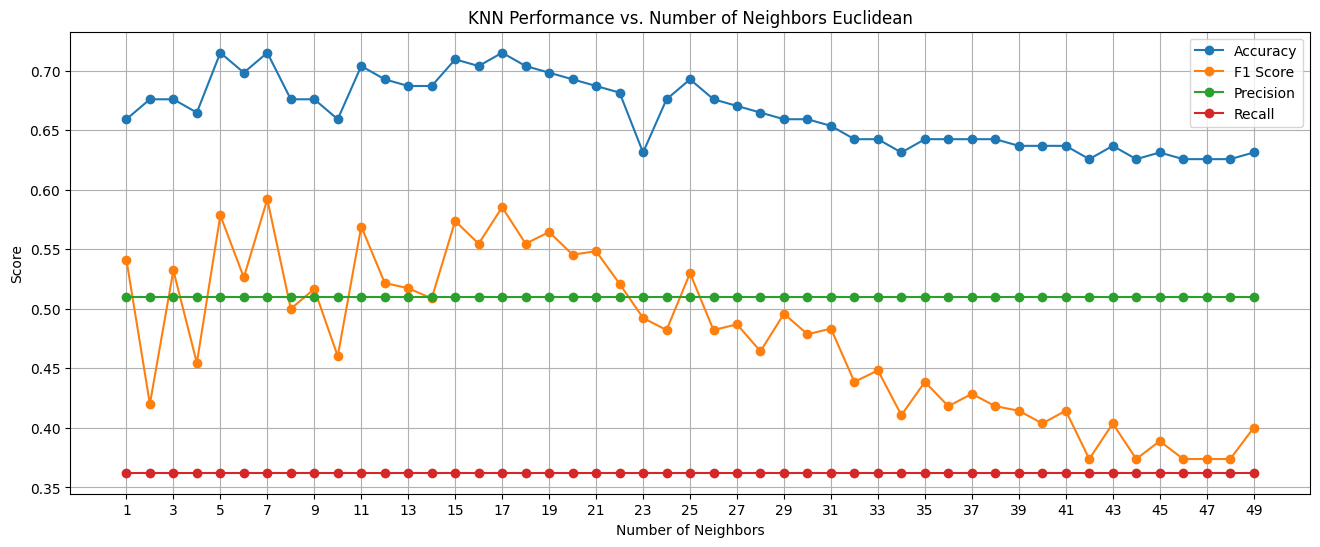

In [68]:
n_neighbors_values = range(1, 50)
knn_accuracy = []
knn_precision = []
knn_recall = []
knn_f1 = []

for n in n_neighbors_values:
    knn = KNeighborsClassifier(n_neighbors=n, metric='manhattan')
    knn.fit(X_train, y_train)
    y_pred_knn = knn.predict(X_test)
    knn_accuracy.append(accuracy_score(y_test, y_pred_knn))
    knn_precision.append(precision)
    knn_recall.append(recall)
    knn_f1.append(f1_score(y_test, y_pred_knn))

plt.figure(figsize=(16, 6))
plt.plot(n_neighbors_values, knn_accuracy, marker='o', label='Accuracy')
plt.plot(n_neighbors_values, knn_f1, marker='o', label='F1 Score')
plt.plot(n_neighbors_values, knn_precision, marker='o', label='Precision')
plt.plot(n_neighbors_values, knn_recall, marker='o', label='Recall')
plt.title('KNN Performance vs. Number of Neighbors Euclidean')
plt.xlabel('Number of Neighbors')
plt.ylabel('Score')
plt.xticks(n_neighbors_values[::2])
plt.legend()
plt.grid(True)
plt.show()

Najlepsze wyniki klasyfikacji otrzymaliśmy dla liczby sąsiadów 5, 6 oraz 7 (najwyższe wartości Accurany oraz F1-score).
Zauważmy, że wartości Precision oraz Recall nie zmieniają się wraz z number_of_neighbors.

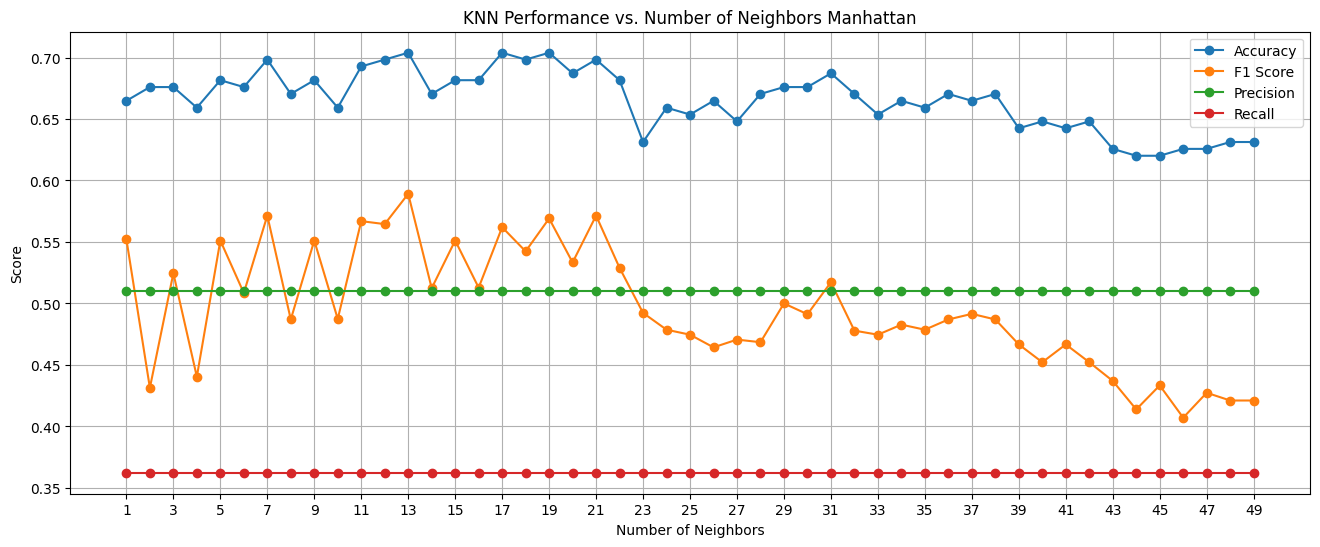

In [70]:
n_neighbors_values = range(1, 50)
knn_accuracy = []
knn_precision = []
knn_recall = []
knn_f1 = []

for n in n_neighbors_values:
    knn = KNeighborsClassifier(n_neighbors=n, metric='euclidean')
    knn.fit(X_train, y_train)
    y_pred_knn = knn.predict(X_test)
    knn_accuracy.append(accuracy_score(y_test, y_pred_knn))
    knn_precision.append(precision)
    knn_recall.append(recall)
    knn_f1.append(f1_score(y_test, y_pred_knn))

plt.figure(figsize=(16, 6))
plt.plot(n_neighbors_values, knn_accuracy, marker='o', label='Accuracy')
plt.plot(n_neighbors_values, knn_f1, marker='o', label='F1 Score')
plt.plot(n_neighbors_values, knn_precision, marker='o', label='Precision')
plt.plot(n_neighbors_values, knn_recall, marker='o', label='Recall')
plt.title('KNN Performance vs. Number of Neighbors Manhattan')
plt.xlabel('Number of Neighbors')
plt.ylabel('Score')
plt.xticks(n_neighbors_values[::2])
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
W metryce euklidesowej najlepsze wyniki klasyfikacji otrzymaliśmy dla liczby sąsiadów 5, 6 oraz 7 (najwyższe wartości Accurany oraz F1-score).
Jednak dla większej liczby sąsiadow (powyżej 20) wyniki są znacznie gorsze niż dla metryki Manhattan.

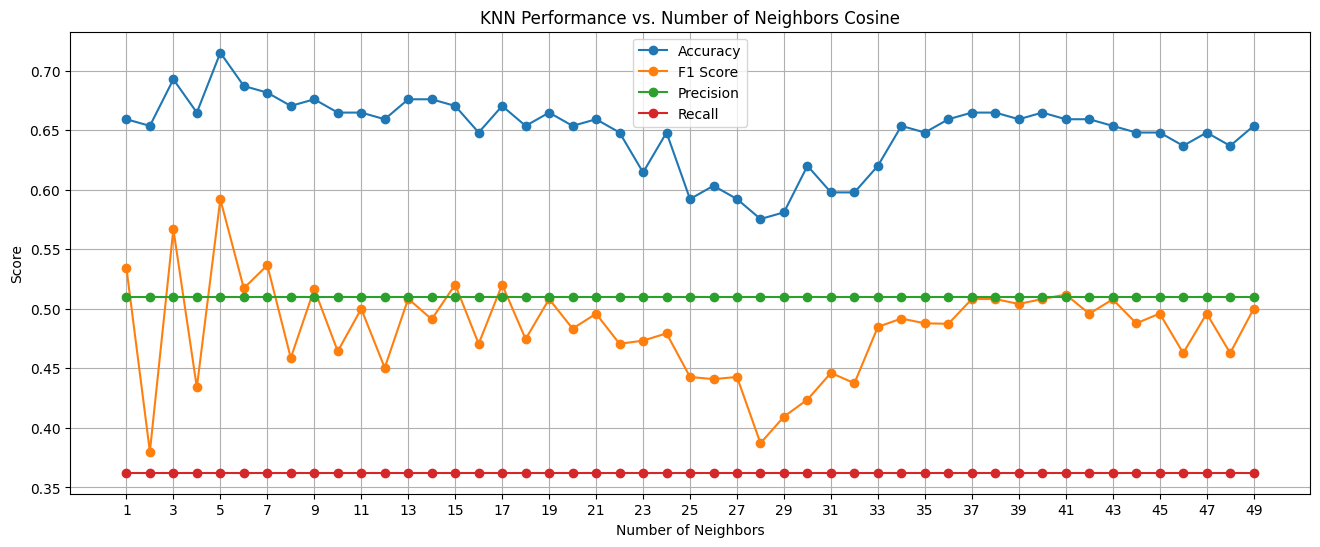

In [71]:
n_neighbors_values = range(1, 50)
knn_accuracy = []
knn_precision = []
knn_recall = []
knn_f1 = []

for n in n_neighbors_values:
    knn = KNeighborsClassifier(n_neighbors=n, metric='cosine')
    knn.fit(X_train, y_train)
    y_pred_knn = knn.predict(X_test)
    knn_accuracy.append(accuracy_score(y_test, y_pred_knn))
    knn_precision.append(precision)
    knn_recall.append(recall)
    knn_f1.append(f1_score(y_test, y_pred_knn))

plt.figure(figsize=(16, 6))
plt.plot(n_neighbors_values, knn_accuracy, marker='o', label='Accuracy')
plt.plot(n_neighbors_values, knn_f1, marker='o', label='F1 Score')
plt.plot(n_neighbors_values, knn_precision, marker='o', label='Precision')
plt.plot(n_neighbors_values, knn_recall, marker='o', label='Recall')
plt.title('KNN Performance vs. Number of Neighbors Cosine')
plt.xlabel('Number of Neighbors')
plt.ylabel('Score')
plt.xticks(n_neighbors_values[::2])
plt.legend()
plt.grid(True)
plt.show()

Dla metryki cosinusowej dla liczby sąsiadów 5, 6, 7 otrzymaliśmy nieznacznie gorsze wyniki od metryki Manhattan,
ale lepsze niż dla metryki Euklidesowej. Dla większej liczby sąsiadów (powyżej 20) wyniki są najgorze ze wszystkich 3 badanych metryk.

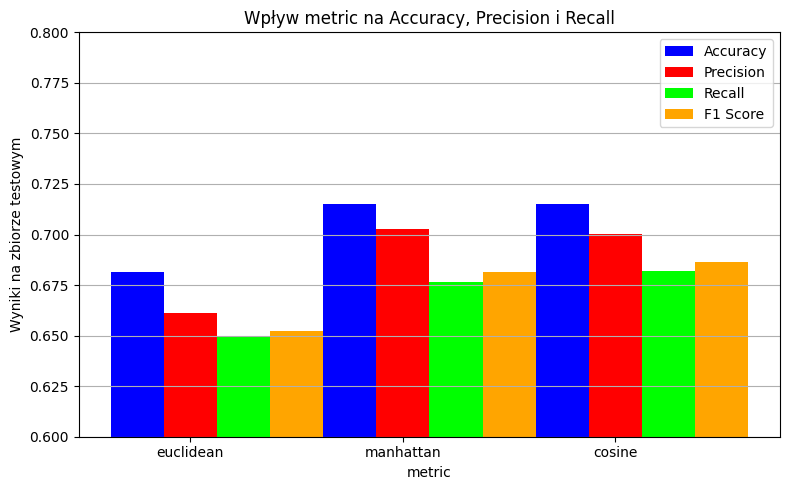

In [75]:
metric = ['euclidean', 'manhattan', 'cosine']
accuracies = []
precisions = []
recalls = []
f1_res = []

for m in metric:
    model = KNeighborsClassifier(n_neighbors=5, metric=m)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracies.append(accuracy_score(y_test, y_pred))
    precisions.append(precision_score(y_test, y_pred, average='macro'))
    recalls.append(recall_score(y_test, y_pred, average='macro'))
    f1_res.append(f1_score(y_test, y_pred, average='macro'))


x = np.arange(len(metric))
width = 0.25

plt.figure(figsize=(8, 5))
plt.bar(x - width, accuracies, width, label='Accuracy', color='blue')
plt.bar(x, precisions, width, label='Precision', color='red')
plt.bar(x + width, recalls, width, label='Recall', color='lime')
plt.bar(x + 2*width, f1_res, width, label='F1 Score', color='orange')

plt.title('Wpływ metric na Accuracy, Precision i Recall')
plt.xlabel('metric')
plt.ylabel('Wyniki na zbiorze testowym')
plt.xticks(x, metric)
plt.ylim(0.6, 0.8)
plt.grid(axis='y')
plt.legend()
plt.tight_layout()
plt.show()



In [ ]:
Widzimy, że najlepsze wyniki dla klasyfikatora KNN uzyskaliśmy dla metryki Manhattan.
Przy metryce cosinusowej otrzymaliśmy nieznacznie gorsze wyniki od metryki Manhattan.
Najmniejszą dokładność klasyfikacji uzyskaliśmy dla metryki euklidesowej.

Może to wynikać z faktu, że w badanym zbiorze danych, który zawiera zarówno cechy numeryczne, jak i kategoryczne.
Do odległości miedzy punktami posiadającymi cechy kategoryczne najlepiej nadają się metryki
Manhattan i cosinusowa, najgorzej radzi sobie metryka euklidesowa, która jest przystosowana szczególnie do danych liczbowych (numerycznych).
